# Homework 2: Machine Learning for Regression

**The goal of this homework is to create a regression model for predicting the car fuel efficiency (column '`fuel_efficiency_mpg`').**

### Getting the data

In [152]:
# !wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

### Loading the data

In [153]:
import pandas as pd

df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [154]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


### Making the column names consistent

In [155]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

### Preparing the dataset

Preparing the dataset

Use only the following columns:

- `'engine_displacement'`,
- `'horsepower'`,
- `'vehicle_weight'`,
- `'model_year'`,
- `'fuel_efficiency_mpg'`

In [156]:
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]

In [157]:
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


### EDA

In [158]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(f"How many unique values are there:  {df[col].nunique()}")
    print("="*50)

engine_displacement
[2180 2390 2320 2130 2580]
How many unique values are there:  127
horsepower
[243. 272. 267. 258. 304.]
How many unique values are there:  153
vehicle_weight
[3870 4210 4240 4490 4510]
How many unique values are there:  176
model_year
[2006 2008 1996 1989 1994]
How many unique values are there:  50
fuel_efficiency_mpg
[31.9 31.3 27.5 28.5 31. ]
How many unique values are there:  188


In [159]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

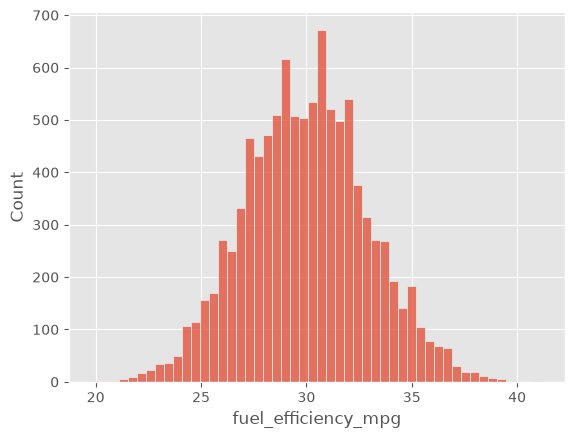

In [160]:
sns.histplot(df.fuel_efficiency_mpg, bins=50);

Look at the `fuel_efficiency_mpg` variable. Does it have a long tail?
No it's much more a normal distribution.

Question 1

There's one column with missing values. What is it?

- 'engine_displacement'
- 'horsepower'
- 'vehicle_weight'
- 'model_year'

In [161]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

It's the `horsepower` column.

Question 2

What's the median (50% percentile) for variable 'horsepower'?

- 204
- 254
- 304
- 354

In [162]:
pd.DataFrame(df['horsepower'].describe()).T

,count,mean,std,min,25%,50%,75%,max
horsepower,9123.0,254.446016,22.844613,171.0,239.0,254.0,270.0,334.0


The median (50%) is 254.0

### Prepare and split the dataset

Shuffle the filtered dataset and create the split exactly as in the lecture:

In [163]:
import numpy as np

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

Question 3

- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
- Which option gives better RMSE?

Options:

- With 0
- With mean
- Both are equally good

In [164]:
df.columns

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year',
       'fuel_efficiency_mpg'],
      dtype='str')

In [165]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

In [166]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [167]:
df_train[base].isnull().sum()

engine_displacement      0
horsepower             538
vehicle_weight           0
model_year               0
dtype: int64

### Utils functions

In [168]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [169]:
# Prepare X with respect to the option 1
def prepare_X_1(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [170]:
# Prepare X with respect to the option 2
def prepare_X_2(df):
    df_num = df[base]
    df_num = df_num.fillna(df['horsepower'].mean())
    X = df_num.values
    return X

In [171]:
# Validation - For option 1
X_train = prepare_X_1(df_train)
y_train = df_train['fuel_efficiency_mpg']
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X_1(df_val)
y_val = df_val['fuel_efficiency_mpg']

y_pred = w0 + X_val.dot(w)

round(rmse(y_val, y_pred), 3)

np.float64(2.205)

In [172]:
# Validation - For option 2
X_train = prepare_X_2(df_train)
y_train = df_train['fuel_efficiency_mpg']
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X_2(df_val)
y_val = df_val['fuel_efficiency_mpg']

y_pred = w0 + X_val.dot(w)

round(rmse(y_val, y_pred), 3)

np.float64(2.202)

Filling missing value with the mean gave us a little bit better performance.

Question 4

- Now let's train a regularized linear regression.
- For this question, fill the NAs with 0.
- Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
- Use RMSE to evaluate the model on the validation dataset.
- Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
- Which r gives the best RMSE?

If multiple options give the same best RMSE, select the smallest r.

Options:

- 0
- 0.01
- 0.1
- 1
- 5
- 10
- 100

In [173]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [174]:
# Validation - For option 1
X_train = prepare_X_1(df_train)
y_train = df_train['fuel_efficiency_mpg']

r = [0, 0.01, 0.1, 1, 5, 10, 100]

for r in r:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X_1(df_val)
    y_val = df_val['fuel_efficiency_mpg']

    y_pred = w0 + X_val.dot(w)

    print(f" For r={r}, \t RMSE={round(rmse(y_val, y_pred), 3)}")

 For r=0, 	 RMSE=2.205
 For r=0.01, 	 RMSE=2.206
 For r=0.1, 	 RMSE=2.224
 For r=1, 	 RMSE=2.349
 For r=5, 	 RMSE=2.409
 For r=10, 	 RMSE=2.419
 For r=100, 	 RMSE=2.429


r=0 is the best value regularizer.

Question 5

- We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
- Round the result to 3 decimal digits (round(std, 3))

What's the value of std?

- 0.006
- 0.016
- 0.029
- 0.036

In [175]:
# seed values
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# set's protion: 60%/20%/20%
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

# Array for storing all the RMSE value in order to compute the std after
all_RMSE = []

for seed in seeds:
    # splitting the dataset
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    # Preparation & feature/target extraction for the training phase
    X_train = prepare_X_1(df_train)
    y_train = df_train['fuel_efficiency_mpg']

    # Training phase
    w0, w = train_linear_regression(X_train, y_train)

    # Preparation & feature/target extraction for the validation phase
    X_val = prepare_X_1(df_val)
    y_val = df_val['fuel_efficiency_mpg']

    # Prdiction on the validation set
    y_pred = w0 + X_val.dot(w)

    # Evaluation
    print(f"For seed={seed}, \t RMSE={round(rmse(y_val, y_pred), 3)}")
    all_RMSE.append(round(rmse(y_val, y_pred), 3))

print("="*50)
print(f"The standard deviation of all scores is: {round(np.std(all_RMSE), 3)}")

For seed=0, 	 RMSE=2.239
For seed=1, 	 RMSE=2.202
For seed=2, 	 RMSE=2.163
For seed=3, 	 RMSE=2.204
For seed=4, 	 RMSE=2.202
For seed=5, 	 RMSE=2.246
For seed=6, 	 RMSE=2.27
For seed=7, 	 RMSE=2.191
For seed=8, 	 RMSE=2.217
For seed=9, 	 RMSE=2.207
The standard deviation of all scores is: 0.029


Question 6

- Split the dataset like previously, use seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with r=0.001.
- What's the RMSE on the test dataset?

Options:

- 0.236
- 2.236
- 22.10
- 221.0

In [176]:
# Combined datasets
n = len(df)
n_test = int(n * 0.2)
n_train = n - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_test = df.iloc[idx[n_train:]]

In [177]:
# Test
X_train = prepare_X_1(df_train)
y_train = df_train['fuel_efficiency_mpg']
w0, w = train_linear_regression_reg(X_train, y_train, r=0.001)

X_test = prepare_X_1(df_test)
y_test = df_test['fuel_efficiency_mpg']

y_pred = w0 + X_test.dot(w)

print("="*13 + " EVALUATION " + "="*13)
print(f"The RMSE on the test dataset is: {round(rmse(y_test, y_pred), 3)}")

============= EVALUATION =============
The RMSE on the test dataset is: 2.236


---